# 03. 모델 활용 방안

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, pickle
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.data import load_raw, clean
from src.features import to_long, build_features
from src.viz import setup_plot_style, DOW_KR

setup_plot_style()
pd.set_option("display.max_columns", 50)
DATA, OUT = ROOT / C.DATA_PATH, ROOT / C.OUTPUT_DIR

required = ["predictions_test.csv", "run_info.json", C.FINAL_MODEL_FILE]
missing = [f for f in required if not (OUT / f).exists()]
if missing:
    raise FileNotFoundError(f"run.py 실행 결과가 없습니다: {missing}")

preds = pd.read_csv(OUT / "predictions_test.csv", parse_dates=["ts", "date"])
info = json.loads((OUT / "run_info.json").read_text(encoding="utf-8"))
selected = info["selected_model"]
with open(OUT / C.FINAL_MODEL_FILE, "rb") as f:
    model = pickle.load(f)
feat = build_features(to_long(clean(load_raw(DATA))[0]))
print("선정 모델:", selected)

선정 모델: lstm_1d


## 1. 테스트 구간 예측 (1주)

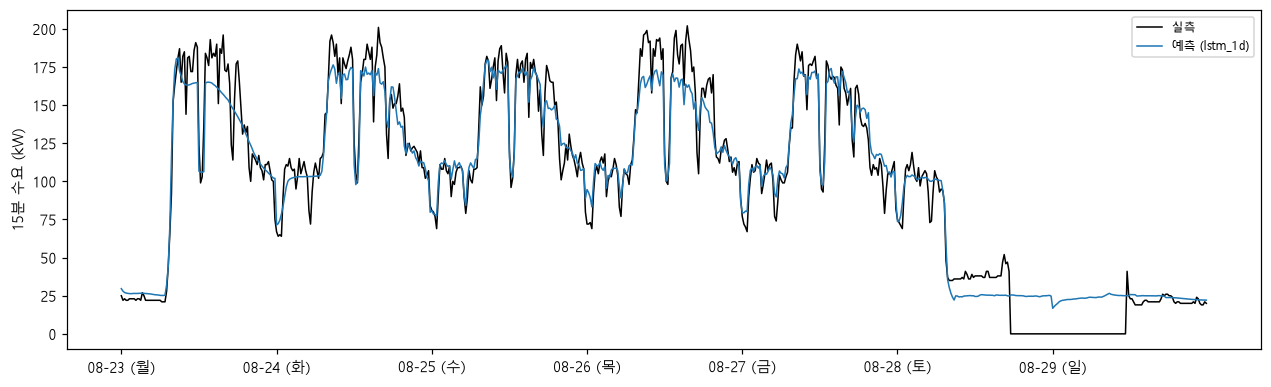

In [2]:
week = pd.date_range(preds["date"].min(), periods=7, freq="D")
w = preds[preds["date"].isin(week)]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(w["ts"], w["kw"], color="black", lw=1, label="실측")
ax.plot(w["ts"], w[selected], color="tab:blue", lw=1, label=f"예측 ({selected})")
ax.set_xticks(week)
ax.set_xticklabels([f"{d:%m-%d} ({DOW_KR[d.dayofweek + 1]})" for d in week])
ax.set_ylabel("15분 수요 (kW)")
ax.legend(fontsize=8, loc="upper right")
plt.show()

## 2. LSTM SHAP

c:\Users\deyby\Desktop\kamp_ai_competition\kamp_ai_competition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


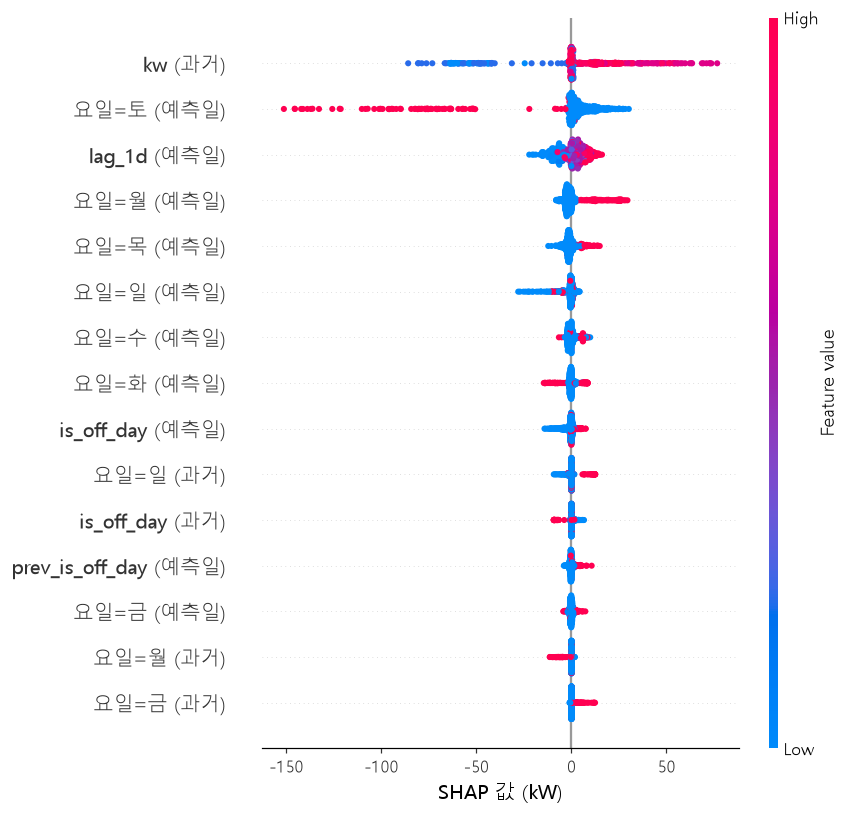

In [3]:
import shap
from src.explain import sequence_shap

train_dates = pd.Series(feat.loc[feat["ts"] < pd.Timestamp(C.TEST_START), "date"].unique())
background = train_dates.sample(50, random_state=C.SEED)
sv, fv, base = sequence_shap(model, feat, week, background)
shap.summary_plot(sv.to_numpy(), fv, max_display=15, show=False, rng=np.random.default_rng(C.SEED))
plt.xlabel("SHAP 값 (kW)")
plt.show()